In [ ]:
!pip install opencv-python -q
!pip install ultralytics -q
!pip install supervision -q
!pip install matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.6/913.6 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 4.0 MB/s eta 0:00:00


In [ ]:
!pip install scikit-learn -q

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans


In [ ]:
image_path='/content/drive/MyDrive/Colab Notebooks/SoccerAnalysis/output_videos/cropped_img.jpg'
image=cv2.imread(image_path)
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

In [ ]:
print(image)

[[[ 89 122  67]
  [ 94 127  72]
  [ 96 129  72]
  ...
  [ 92 128  66]
  [ 90 129  66]
  [ 90 129  66]]

 [[ 96 129  74]
  [ 98 131  76]
  [ 96 129  72]
  ...
  [ 90 126  64]
  [ 88 127  64]
  [ 88 127  64]]

 [[100 130  76]
  [ 99 129  75]
  [ 96 127  70]
  ...
  [ 86 125  62]
  [ 87 126  63]
  [ 87 126  63]]

 ...

 [[ 78 111  56]
  [ 79 112  57]
  [ 79 112  57]
  ...
  [140 162 116]
  [131 153 106]
  [124 148  98]]

 [[ 84 117  62]
  [ 85 118  63]
  [ 84 117  62]
  ...
  [ 93 117  69]
  [ 90 114  64]
  [ 90 117  66]]

 [[ 89 122  67]
  [ 86 119  64]
  [ 82 115  60]
  ...
  [ 64  92  41]
  [ 68  96  45]
  [ 75 103  52]]]


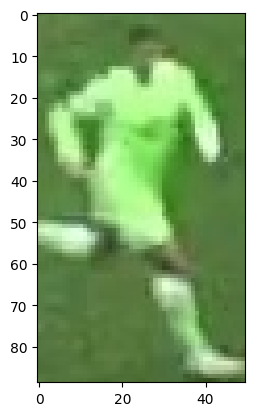

In [ ]:
plt.imshow(image)

In [ ]:

plt.show()

# take the top half of the image as tshirt is in top half

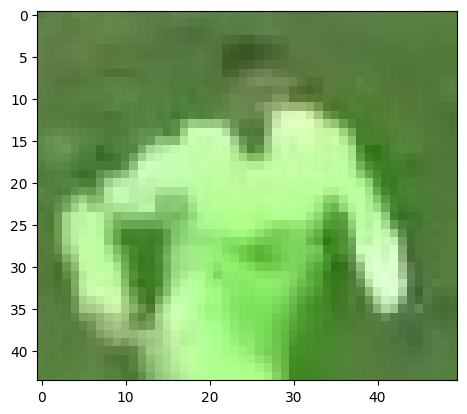

In [ ]:
top_half_image=image[0:int(image.shape[0]/2),:]
plt.imshow(top_half_image)
plt.show()

# Cluster the image into two clusters -- background image seperate and player image seperate

Kmeans:  KMeans(n_clusters=2, random_state=0)
Kmeans fit:  KMeans(n_clusters=2, random_state=0)
[1 1 1 ... 1 1 1]
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


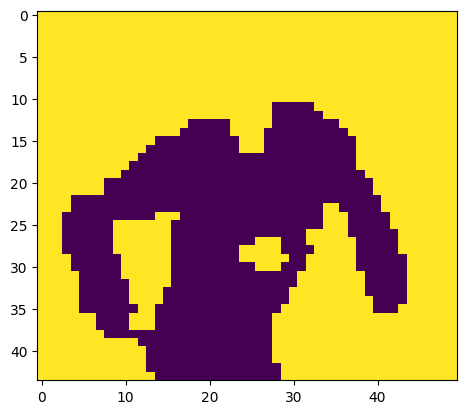

In [ ]:
# reshape the image into 2d array
image_2D=top_half_image.reshape(-1,3)

#perform kmean clustering
kmeans = KMeans(n_clusters=2, random_state=0)
print(f'Kmeans:  {kmeans}')
kmeans.fit(image_2D)
print(f'Kmeans fit:  {kmeans}')

#get cluster labels
labels=kmeans.labels_
print(labels)

#reshape the labels into the original image shape
clustered_image=labels.reshape(top_half_image.shape[0],top_half_image.shape[1])
print(clustered_image)
#display the clustered image
plt.imshow(clustered_image)
plt.show()

In [ ]:
corner_clusters=[clustered_image[0,0],clustered_image[0,-1],clustered_image[-1,0],clustered_image[-1,-1]]
print(corner_clusters)
non_player_cluster=max(set(corner_clusters),key=corner_clusters.count)
print(non_player_cluster)

[1, 1, 1, 1]
1


In [ ]:
player_cluster=1-non_player_cluster
print(player_cluster)

0


In [ ]:
player_cluster_center = kmeans.cluster_centers_[player_cluster]
print(f'Kmeans.cluster_centers_ : {kmeans.cluster_centers_}')
print("Player cluster center (RGB):", player_cluster_center)

Kmeans.cluster_centers_ : [[170.81879195 235.24966443 142.60134228]
 [ 86.30721649 130.51546392  62.30721649]]
Player cluster center (RGB): [170.81879195 235.24966443 142.60134228]
